### Import de les llibreries necessàries per l'execució del notebook

In [1]:
import matplotlib.pyplot as plt
plt.rcParams['image.interpolation'] = 'none'
import numpy as np
import cv2
import math
from sklearn.mixture import GaussianMixture
from scipy.ndimage import gaussian_filter1d
import itertools
from sklearn.cluster import DBSCAN
import random

### Funció auxiliar per visualitzar imatges

In [2]:
def display_images(imgs, titles, width=5):
    n = len(imgs)
    rows = math.ceil(n / 3)
    cols = n // rows
    h, w = imgs[0].shape[:2]
    fig, axs = plt.subplots(rows, cols, figsize=(width * cols, width * h / w * rows))
    axs = axs.flatten()
    for i in range(rows * cols):
        if i < n:
            img = imgs[i]
            axs[i].imshow(img, cmap='gray' if img.ndim == 2 else None)
            axs[i].set_title(titles[i])
        axs[i].axis('off')
    plt.tight_layout()
    plt.show()


def to_float(img):
    img = img.astype(np.float64)
    return (img - np.min(img)) / (np.max(img) - np.min(img))

def to_uint8(img):
    norm = (img - np.min(img)) / (np.max(img) - np.min(img))
    return np.round(norm * 255).astype(np.uint8)

### Imatges de prova

In [3]:
path = "../data/examples_cropped/heon_IMG_0534.JPG" # Ombres
# path = "../data/examples_cropped/sam_IMG_1379.jpg" # Vía
# path = "../data/examples_cropped/heon_IMG_0520.JPG" # Il·luminació horrible
# path = "../data/examples_cropped/sam_IMG_6482.jpg" # Neu
# path = "../data/examples_cropped/heon_IMG_0588.JPG" # Normal
# path = "../data/examples_cropped/sam_IMG_1397.jpg" # Esborrat
# path = "../data/examples_cropped/sam_IMG_1344.jpg" # Farola

# path = "../data/pedestrian-traffic-lights/sam_IMG_2406.JPG"


img = plt.imread(path)
height, width, channels = img.shape
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

display_images([img, gray], ['Imatge original', 'Escala de grisos'])

<Figure size 1000x404.851 with 2 Axes>

### Primeres proves: imatge amb filtres de mediana, Gaussià, bilateral i morfologia de màxims

In [4]:
src = gray

med = cv2.medianBlur(src, 5)

sigma = 1.5
ksize = round(6 * sigma + 1)
ksize = ksize + 1 - (ksize % 2)
blur = cv2.GaussianBlur(src, (ksize, ksize), sigma)

bilat = cv2.bilateralFilter(src, d=6, sigmaColor=75, sigmaSpace=75)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5,5))
max = cv2.morphologyEx(src, cv2.MORPH_DILATE, kernel)

display_images([med, blur, bilat, max], ['Filtre de mediana', 'Filtre Gaussià', 'Filtre bilateral', 'Morfologia de màxims (dilate)'])

<Figure size 1000x809.701 with 4 Axes>

### Primer apropament: Cerca del millor threshold comparant Otsu VS Mixtura de Gaussianes

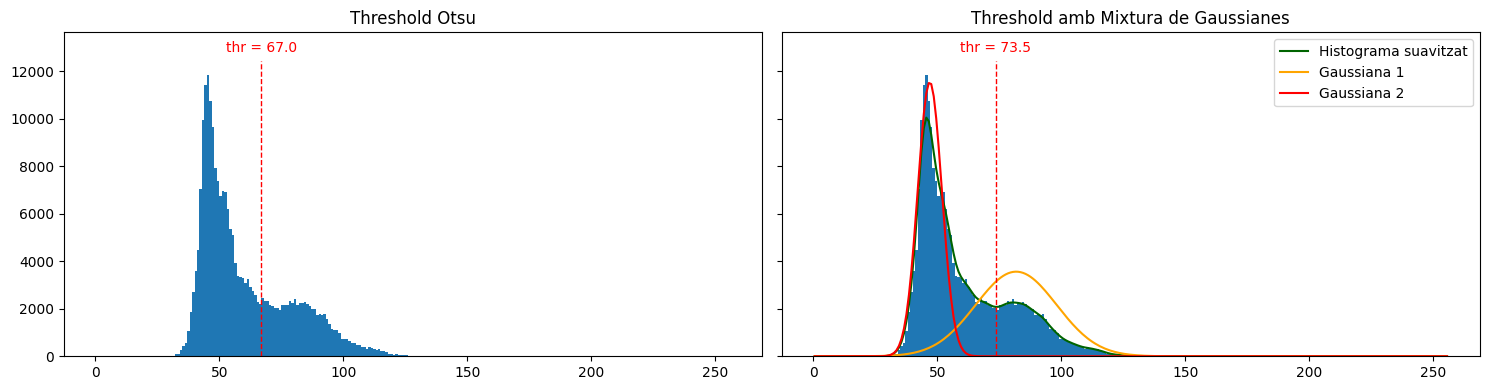

In [5]:
src = med

# Otsu
hist, bins = np.histogram(src, bins=256, range=(0, 256))
thr1, bw = cv2.threshold(src, 0, 256, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Mixtura de Gaussianes
sample = cv2.resize(src, (14, 14), interpolation=cv2.INTER_CUBIC).reshape(-1, 1)
gmm = GaussianMixture(n_components=2, covariance_type='full')
gmm.fit(sample)
means = gmm.means_.flatten()
covs = gmm.covariances_.flatten()
weights = gmm.weights_.flatten()
m1, m2 = np.sort(means)

hist_smooth = gaussian_filter1d(hist, sigma=2)
bin_centers = (bins[:-1] + bins[1:]) / 2

mask = (bin_centers > m1) & (bin_centers < m2)
thr2 = bin_centers[mask][np.argmin(hist_smooth[mask])]

pdf1 = weights[0] * np.exp(-0.5 * ((bin_centers - means[0])**2) / covs[0]) / np.sqrt(2 * np.pi * covs[0])
pdf2 = weights[1] * np.exp(-0.5 * ((bin_centers - means[1])**2) / covs[1]) / np.sqrt(2 * np.pi * covs[1])
pdf_scale = np.max(hist) / np.max(pdf1 + pdf2)

# Gràfica
fig, axs = plt.subplots(1, 2, figsize=(15, 4), sharey=True)

axs[0].bar((bins[1:] + bins[:-1]) / 2, hist, width=1)
axs[0].axvline(thr1, color='red', linestyle='--', linewidth=1, ymax=0.91)
axs[0].text(float(thr1), np.max(hist) * 1.08, f'thr = {thr1:.1f}', color='red', ha='center')
axs[0].set_ylim(0, np.max(hist) * 1.15)
axs[0].set_title('Threshold Otsu')

axs[1].bar(bin_centers, hist, width=1)
axs[1].plot(bin_centers, hist_smooth, color='darkgreen', label='Histograma suavitzat')
axs[1].plot(bin_centers, pdf1 * pdf_scale, color='orange', label='Gaussiana 1')
axs[1].plot(bin_centers, pdf2 * pdf_scale, color='red', label='Gaussiana 2')
axs[1].axvline(thr2, color='red', linestyle='--', linewidth=1, ymax=0.91)
axs[1].text(float(thr2), np.max(hist) * 1.08, f'thr = {thr2:.1f}', color='red', ha='center')
axs[1].set_ylim(0, np.max(hist) * 1.15)
axs[1].set_title('Threshold amb Mixtura de Gaussianes')
axs[1].legend(loc='upper right')

plt.tight_layout()
plt.show()


### Imatge binària representada amb els dos thresholds trobats

In [6]:
src = med

bw1 = 255*(src > thr1).astype(np.uint8)
bw2 = 255*(src > thr2).astype(np.uint8)


display_images([src, bw1, bw2], ['Imatge inicial', 'Threshold Otsu', 'Threshold amb Mixtura de Gaussianes'])

<Figure size 1500x404.851 with 3 Axes>

### Problema del Top-Hat: resolució amb kernel petit VS kernel gran


In [7]:
src = med

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 10))
top_hat1 = cv2.morphologyEx(src, cv2.MORPH_TOPHAT, kernel)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (60, 60))
top_hat2 = cv2.morphologyEx(src, cv2.MORPH_TOPHAT, kernel)

_, bw4 = cv2.threshold(top_hat2, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

display_images([src, top_hat1, top_hat2, bw4], ['Imatge base', 'Top-hat amb kernel petit', 'Top-hat amb kernel gran', 'Threshold Otsu'])

<Figure size 1000x809.701 with 4 Axes>

### Segon apropament: Tractament d'imatge mitjançant equalització adaptativa del contrast i threshold OTSU

In [8]:
src = med

clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
eq = clahe.apply(med)

eq_med = cv2.medianBlur(eq, ksize=5)

_, bw3 = cv2.threshold(eq_med, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

display_images([eq, eq_med, bw3], ['Equalització adaptativa del contrast', 'Filtre de mediana', 'Threshold Otsu'])

<Figure size 1500x404.851 with 3 Axes>

### Cerca de les vores de la imatge mitjançant Canny

In [9]:
src = bw2

edges = cv2.Canny(src, 50, 150, apertureSize=3)

plt.figure(figsize=(10, 10))
plt.imshow(edges, cmap="gray")
plt.axis('off')
plt.show()

<Figure size 1000x1000 with 1 Axes>

### Cerca de les vores de la imatge mitjançant LoG (Laplacian of Gaussian)

In [10]:
src = bw2

src_blur = cv2.GaussianBlur(src, (5,5), 0)
lap = cv2.Laplacian(src_blur, ddepth=cv2.CV_64F)

# Zero-crossings
z1 = np.roll(lap, 1, axis=0) * np.roll(lap, -1, axis=0)
z2 = np.roll(lap, 1, axis=1) * np.roll(lap, -1, axis=1)
edges = np.logical_or(z1 < 0, z2 < 0).astype(np.uint8) * 255


display_images([src_blur, edges], ['Imatge suavitzada', 'Edges LoG'])

<Figure size 1000x404.851 with 2 Axes>

### Detecció de línies a la imatge: aplicació de Hough

In [11]:
def get_intersection(l1, l2):
    rho1, theta1 = l1
    rho2, theta2 = l2
    A = np.array([
        [np.cos(theta1), np.sin(theta1)],
        [np.cos(theta2), np.sin(theta2)]
    ])
    b = np.array([[rho1], [rho2]])
    if np.abs(np.linalg.det(A)) < 1e-6:
        return None
    intersection = np.linalg.solve(A, b)
    return intersection.flatten()

def point_line_distance(x0, y0, rho, theta):
    return abs(x0 * np.cos(theta) + y0 * np.sin(theta) - rho)

In [12]:
def draw_lines(img, lines, title=None, polar=True, color=(255, 0, 0), thickness=1):
    img_copy = img.copy()
    if polar:
        for rho, theta in lines:
            a, b = np.cos(theta), np.sin(theta)
            x0, y0 = a * rho, b * rho
            x1, y1 = int(x0 + 1000 * -b), int(y0 + 1000 * a)
            x2, y2 = int(x0 - 1000 * -b), int(y0 - 1000 * a)
            cv2.line(img_copy, (x1, y1), (x2, y2), color, thickness)
    else:
        for x1, y1, x2, y2 in lines:
            cv2.line(img_copy, (x1, y1), (x2, y2), color, thickness)

    plt.figure(figsize=(10, 10))
    plt.imshow(img_copy)
    if title is not None: plt.title(title)
    plt.axis('off')
    plt.show()

In [13]:
def get_filtered_lines(edges, min_cluster_size=5, min_separation=1, distance_thresh=30, eps=40):
    few_raw = cv2.HoughLines(edges, 1, np.pi/180, threshold=240)
    raw = cv2.HoughLines(edges, 1, np.pi/180, threshold=150)
    if few_raw is None or raw is None:
        return [], []

    few_lines = few_raw[:, 0, :]
    lines = raw[:, 0, :]

    draw_lines(img, few_lines, "Hough restrictiu", polar=True)
    draw_lines(img, lines, "Hough molt tolerant", polar=True)

    intersections = []
    for l1, l2 in itertools.combinations(few_lines, 2):
        pt = get_intersection(l1, l2)
        if pt is not None and np.all(np.isfinite(pt)):
            intersections.append(pt)
    if not intersections:
        return few_lines, []
    intersections = np.array(intersections)

    clustering = DBSCAN(eps=eps, min_samples=min_cluster_size).fit(intersections)
    labels = clustering.labels_

    if np.sum(labels != -1)==0:
        return few_lines, []

    unique_labels = np.unique(labels[labels != -1])
    cluster_sizes = np.array([np.sum(labels == k) for k in unique_labels])
    centroids = np.stack([intersections[labels == k].mean(axis=0) for k in unique_labels])
    centroids = centroids[np.argsort(cluster_sizes)[::-1]]

    points = []
    for centroid in centroids:
        if all(centroid[0]-p[0]>min_separation and centroid[1]-p[1]>min_separation for p in points):
            points.append(centroid)
    points = np.array(points)

    filtered_lines = []
    for rho, theta in lines:
        for x, y in points:
            if point_line_distance(x, y, rho, theta) < distance_thresh:
                filtered_lines.append([rho, theta])
                break
    filtered_lines = np.array(filtered_lines)

    return filtered_lines, points

In [14]:
def filter_hough_rho(lines, rho_eps=10):
    if len(lines) == 0:
        return np.array([])

    lines = np.array(lines)
    selected = []

    for rho, theta in lines:
        keep = True
        for r_sel, t_sel in selected:
            if abs(rho - r_sel) <= rho_eps:
                keep = False
                break
        if keep:
            selected.append([rho, theta])

    return np.array(selected)

In [15]:
def filter_lines_by_intersection(lines, shape):
    if len(lines) == 0:
        return np.array([])

    lines = np.array(lines)
    h, w = shape[:2]
    theta_mean = np.mean(lines[:, 1])
    keep = np.ones(len(lines), dtype=bool)

    def get_line_points(rho, theta):
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = np.array([x0 + 1000 * -b, y0 + 1000 * a])
        pt2 = np.array([x0 - 1000 * -b, y0 - 1000 * a])
        return pt1, pt2

    def intersection(p1, p2, q1, q2):
        A = np.array([[p2[0] - p1[0], q1[0] - q2[0]],
                      [p2[1] - p1[1], q1[1] - q2[1]]])
        b = np.array([q1[0] - p1[0], q1[1] - p1[1]])
        if np.linalg.matrix_rank(A) < 2:
            return None
        t = np.linalg.solve(A, b)
        return p1 + t[0] * (p2 - p1)

    for i in range(len(lines)):
        if not keep[i]:
            continue
        rho1, theta1 = lines[i]
        p1, p2 = get_line_points(rho1, theta1)
        for j in range(i + 1, len(lines)):
            if not keep[j]:
                continue
            rho2, theta2 = lines[j]
            q1, q2 = get_line_points(rho2, theta2)
            inter = intersection(p1, p2, q1, q2)
            if inter is not None:
                x, y = inter
                if 0 <= x < w and 0 <= y < h:
                    dist_i = abs(theta1 - theta_mean)
                    dist_j = abs(theta2 - theta_mean)
                    if dist_i > dist_j:
                        keep[i] = False
                        break
                    else:
                        keep[j] = False

    return lines[keep]



### Línies detectades sobre la imatge, dibuixades infinitament llargues per la visualització

In [16]:
filtered_lines, points = get_filtered_lines(edges)
representative_lines = filter_lines_by_intersection(filtered_lines, img.shape)
draw_lines(img, filtered_lines, "filtrat_fuga")
draw_lines(img, representative_lines, "filtrat_proximitat")
points

<Figure size 1000x1000 with 1 Axes>

<Figure size 1000x1000 with 1 Axes>

<Figure size 1000x1000 with 1 Axes>

<Figure size 1000x1000 with 1 Axes>

array([[4055.1902  ,   24.323368],
       [4670.825   ,   27.193989]], dtype=float32)

### Limitació de les línies trobades a la imatge segoons la longitud de les vores trobades anteriorment amb LoG

In [17]:
def segment_from_rho_theta(rho, theta, edge_img, epsilon=1.0):

    ys, xs = np.nonzero(edge_img) 
    pts = np.stack([xs, ys], axis=1).astype(np.float32)

    n = np.array([np.cos(theta), np.sin(theta)]) 
    v = np.array([-np.sin(theta),  np.cos(theta)])
    d = np.abs(pts @ n - rho)
    on_line = pts[d < epsilon]

    if len(on_line) < 2:
        return None
    
    t = on_line @ v
    p_min = on_line[np.argmin(t)]
    p_max = on_line[np.argmax(t)]
    
    return tuple(p_min.astype(int)), tuple(p_max.astype(int))


In [18]:
img_draw = img.copy()

for (rho, theta) in representative_lines:
    extremos = segment_from_rho_theta(rho, theta, edges, epsilon=1.5)
    if extremos:
        cv2.line(img_draw, *extremos, (255,0,0), 1)


plt.figure(figsize=(8, 8))

plt.imshow(img_draw)
plt.axis("off")
plt.title("Línees trobades a la imatge")
plt.show()


<Figure size 800x800 with 1 Axes>

#### Càlcul dels extrems de cada línia, tant verticals com horitzontals

In [19]:
def contar_puntos_cercanos(p1, p2, pts, dist):
    pts = np.asarray(pts, dtype=float)
    p1  = np.asarray(p1,  dtype=float)
    p2  = np.asarray(p2,  dtype=float)

    v = p2 - p1
    norm_v = np.linalg.norm(v)

    if norm_v == 0:
        raise ValueError("p1 y p2 no poden coincidir.")
    dif   = p1 - pts
    cross = v[0] * dif[:, 1] - v[1] * dif[:, 0]

    dists = np.abs(cross) / norm_v
    return np.sum(dists < dist)


In [20]:
def get_vertical_lines(lista_extremos, dist=20, n_iter=100):
    n_lines = len(lista_extremos)
    best_p=(0,0)
    best_k=0
    if lista_extremos is not None:
            for i in range(n_iter):
                p1 = lista_extremos[random.randint(0, n_lines-1)]
                p2 = lista_extremos[random.randint(0, n_lines-1)]
                while np.all(p1 == p2):
                    p2 = lista_extremos[random.randint(0, n_lines-1)]
                k = contar_puntos_cercanos(p1,p2, lista_extremos, dist)
                if k > best_k:
                    best_k = k
                    best_p = (p1, p2)
    return best_p

In [21]:
def intersect_polar_with_segment(rho, theta, segment, eps=1e-6):
    (x1, y1), (x2, y2) = segment
    dx, dy = x2 - x1, y2 - y1
    denom = dx*np.cos(theta) + dy*np.sin(theta)
    if abs(denom) < eps:
        return None
    t = (rho - (x1*np.cos(theta) + y1*np.sin(theta))) / denom
    x = x1 + t*dx
    y = y1 + t*dy
    return (int(round(x)), int(round(y)))

In [22]:
def intersect_polar_with_segment(rho, theta, segment, eps=1e-6):
    (x1, y1), (x2, y2) = segment
    dx, dy = x2 - x1, y2 - y1
    denom = dx*np.cos(theta) + dy*np.sin(theta)
    if abs(denom) < eps:
        return None
    t = (rho - (x1*np.cos(theta) + y1*np.sin(theta))) / denom
    x = x1 + t*dx
    y = y1 + t*dy
    return (int(round(x)), int(round(y)))

In [23]:
eps = 1e-6
lista_extremos = []
h, w = img.shape[:2]
img_draw = img.copy()


for (rho, theta) in representative_lines:
    extremos = segment_from_rho_theta(rho, theta, edges, epsilon=1.5)
    if extremos is not None:
        lista_extremos.append(extremos)
lista_extremos = np.array(lista_extremos)
izq = lista_extremos[:, 0]
der = lista_extremos[:, 1]
p_izq=get_vertical_lines(izq, dist=20, n_iter=100)
p_der=get_vertical_lines(der, dist=20, n_iter=100)

### Càlcul del punt mig i representació de línies i punt mig

In [24]:
h, w = img.shape[:2]
img_draw = img.copy()
lista_midpoints = []

# Dibuixar verticals
for linea in (p_izq, p_der):
    (x1, y1), (x2, y2) = linea
    dx, dy = x2 - x1, y2 - y1
    pts = []
    if abs(dx) > eps:
        for xb in (0, w):
            t = (xb - x1)/dx
            y = y1 + t*dy
            if 0 <= y <= h:
                pts.append((xb, int(round(y))))
    if abs(dy) > eps:
        for yb in (0, h):
            t = (yb - y1)/dy
            x = x1 + t*dx
            if 0 <= x <= w:
                pts.append((int(round(x)), yb))
    if len(pts) >= 2:
        cv2.line(img_draw, pts[0], pts[1], (0,255,0), 1)

# Processat de linies horitzontals
for rho, theta in representative_lines:
    sin_t, cos_t = np.sin(theta), np.cos(theta)
    if abs(sin_t) < eps:
        continue

    # Intersecions
    pi = intersect_polar_with_segment(rho, theta, p_izq)
    pd = intersect_polar_with_segment(rho, theta, p_der)

    # Calcul i filtrat de interseccions
    border = []
    y0 = (rho - 0*cos_t)/sin_t
    yw = (rho - w*cos_t)/sin_t

    if 0 <= y0 <= h: border.append((0, int(round(y0))))
    if 0 <= yw <= h: border.append((w, int(round(yw))))

    x0 = (rho - 0*sin_t)/cos_t if abs(cos_t)>eps else None
    xh = (rho - h*sin_t)/cos_t if abs(cos_t)>eps else None
    
    if x0 is not None and 0 <= x0 <= w: border.append((int(round(x0)), 0))
    if xh is not None and 0 <= xh <= w: border.append((int(round(xh)), h))
    
    if len(border) < 2:
        continue
    
    border = sorted(border, key=lambda p: p[0])
    start_border, end_border = border[0], border[-1]

    # Seleccio de punts: interseccions si existeixen, si no, els extrems de la imatge
    start = pi if pi is not None else start_border
    end   = pd if pd is not None else end_border

    cv2.line(img_draw, start, end, (255,0,0), 1)

    # Calcul de punt mitjà
    mx = int(round((start[0] + end[0]) / 2))
    my = int(round((start[1] + end[1]) / 2))
    lista_midpoints.append((mx, my))

plt.figure(figsize=(8, 8))

for (mx, my) in lista_midpoints:
    cv2.circle(img_draw, (mx, my), radius=3, color=(0,255,255), thickness=-1)

plt.imshow(img_draw)
plt.axis('off')
plt.title('Imatge amb línies horitzontals, verticals i punts mitjans')
plt.show()


<Figure size 800x800 with 1 Axes>

### Càlcul de l'angle de la imatge respecte la vertical

In [25]:
from sklearn.linear_model import RANSACRegressor, LinearRegression

pts = np.array(lista_midpoints)
xs, ys = pts[:,0], pts[:,1]
X = xs.reshape(-1,1)
y = ys

ransac = RANSACRegressor(LinearRegression(), 
                         residual_threshold=w * 0.005,
                         max_trials=10000)
ransac.fit(X, y)


m = 1/ransac.estimator_.coef_[0]
angle_rad = np.atan(m)
angle_deg = angle_rad * 180/np.pi

# m = ransac.estimator_.coef_[0]
# angle_rad = np.arctan(m)
# angle_deg = np.degrees(angle_rad)

# angle_to_vertical = abs(90 - abs(angle_deg))
print("Inliers:", ransac.inlier_mask_.sum(), "/", len(xs))
print(f"RANSAC slope m = {m:.4f}, angle = {angle_deg:.2f}°")


Inliers: 19 / 20
RANSAC slope m = 0.9284, angle = 42.87°


In [26]:
# # Calcular imagen integral
# integral = cv2.integral(gray)

# # Tamaño de la ventana
# w, h = 8, 8
# half_h = h // 2

# # Crear un mapa para guardar los valores de la feature
# feature_map = np.zeros((gray.shape[0] - h, gray.shape[1] - w))

# # Función para suma de rectángulo
# def rect_sum(ii, x, y, w, h):
#     A = ii[y][x]
#     B = ii[y][x + w]
#     C = ii[y + h][x]
#     D = ii[y + h][x + w]
#     return D - B - C + A

# # Escanear con ventana deslizante
# for y in range(0, gray.shape[0] - h):
#     for x in range(0, gray.shape[1] - w):
#         top = rect_sum(integral, x, y, w, half_h)
#         bottom = rect_sum(integral, x, y + half_h, w, half_h)
#         feature_value = top - bottom
#         feature_map[y, x] = feature_value

# # Visualizar el mapa de valores
# plt.figure(figsize=(10, 6))
# plt.imshow(feature_map, cmap='seismic', interpolation='nearest')
# plt.colorbar(label='Haar-like Feature Value')
# plt.title('Mapa de características Haar-like (dos rectángulos horizontales)')
# plt.axis('off')
# plt.show()

In [27]:
# integral = cv2.integral(gray)

# w, h = 8, 8
# half_w = w // 2

# feature_map = np.zeros((gray.shape[0] - h, gray.shape[1] - w))

# def rect_sum(ii, x, y, w, h):
#     A = ii[y][x]
#     B = ii[y][x + w]
#     C = ii[y + h][x]
#     D = ii[y + h][x + w]
#     return D - B - C + A

# for y in range(0, gray.shape[0] - h):
#     for x in range(0, gray.shape[1] - w):
#         left = rect_sum(integral, x, y, half_w, h)
#         right = rect_sum(integral, x + half_w, y, half_w, h)
#         feature_value = -left + right
#         feature_map[y, x] = feature_value

# plt.figure(figsize=(10, 6))
# plt.imshow(feature_map, cmap='viridis', interpolation='nearest')
# plt.colorbar(label='Haar-like Feature Value')
# plt.title('Haar-like Feature Map (two vertical rectangles)')
# plt.axis('off')
# plt.show()
